### Change 3dcnnlstm to 2dcnnlstm

### 1. Load data

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)


2026-01-27 10:37:05.433939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-27 10:37:06.445417: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-27 10:37:24.515755: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/mnt/d/Myworkplace/Python/violence-movies/.venv/lib/python3.12/site-

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    TimeDistributed, GlobalAveragePooling2D,
    LSTM, Dropout, Dense
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score
from pathlib import Path
import gc

try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    # Jupyter notebook fallback
    BASE_DIR = Path.cwd().parent

def load_data(folders, labels, base_path, frame_count=10):
    data = []
    targets = []
    for folder in folders:
        folder_path = os.path.join(base_path, folder)
        for video_folder in os.listdir(folder_path):
            video_path = os.path.join(folder_path, video_folder)
            frames = []
            for frame_file in sorted(os.listdir(video_path))[:frame_count]:
                frame_path = os.path.join(video_path, frame_file)
                frame = cv2.imread(frame_path)
                frame = cv2.resize(frame, (112, 112))
                frames.append(frame)

            # for i, frame in enumerate(frames):
            #     cv2.imshow("Resized Frame (64x64)", frame)
            #     key = cv2.waitKey(0)
            #     if key == 27:  # ESC
            #         cv2.destroyAllWindows()
            #         return None, None  # stop after first video
            # cv2.destroyAllWindows()

            if len(frames) < frame_count:
                frames.extend([np.zeros_like(frames[0])]*(frame_count - len(frames)))
            data.append(frames)
            targets.append(labels[folder])
    return np.array(data), np.array(targets)

base_path = BASE_DIR / "data" / "processed" / "violence-detection-dataset"
folders = ["high-level violence_frames", "low-level violence_frames", "non-violence_frames"]
labels = {"high-level violence_frames": 0, "low-level violence_frames": 1, "non-violence_frames": 2}

data, targets = load_data(folders, labels, base_path)
data = data / 255.0

print(f"Data shape: {data.shape}")
print(f"Targets shape: {targets.shape}")

Data shape: (350, 10, 112, 112, 3)
Targets shape: (350,)


### 2. Create model

In [3]:
# change maxpooling3D from (2,2,2) to (1,2,2)
def create_model(input_shape, num_classes, conv_filters, lstm_units, dropout_rate=0.5):
    # (batch, 10, 64, 64, 3)
    inputs = Input(shape=input_shape)    

    # -------- Block 1 --------
    # (batch, 10, 112, 112, conv_filters)
    x = TimeDistributed(
        Conv2D(conv_filters, (3, 3), activation="relu", padding="same")
    )(inputs)
    # (batch, 10, 56, 56, conv_filters)
    x = TimeDistributed(MaxPooling2D((2, 2)))(x)

    # -------- Block 2 --------
    # (batch, 10, 56, 56, conv_filters)
    x = TimeDistributed(
        Conv2D(conv_filters, (3, 3), activation="relu", padding="same")
    )(x)
    # (batch, 10, 28, 28, conv_filters)
    x = TimeDistributed(MaxPooling2D((2, 2)))(x)

    # -------- Block 3 --------
    # (batch, 10, 28, 28, conv_filters)
    x = TimeDistributed(
        Conv2D(conv_filters, (3, 3), activation="relu", padding="same")
    )(x)
    # (batch, 10, 14, 14, conv_filters)
    x = TimeDistributed(MaxPooling2D((2, 2)))(x)

    # -------- Spatial compression --------
    # (batch, 10, conv_filters)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    # -------- Temporal modeling --------
    # (batch, lstm_units)
    x = LSTM(lstm_units)(x)
    x = Dropout(dropout_rate)(x)

    # -------- Classification head --------
    # (batch, 256)
    x = Dense(256, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

input_shape = (10, 112, 112, 3)
num_classes = 3
# conv_filters_list = [32, 64, 128]
# lstm_units_list = [64, 128]
conv_filters_list = [64]
lstm_units_list = [64]
# conv_filters_list = [128]
# lstm_units_list = [128]
dropout_rate_list = [0.2,0.3,0.4,0.5]
results_neurons = {}

# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
mean_fpr = np.linspace(0, 1, 100)

### 3. Train

In [ ]:
for conv_filters in conv_filters_list:
    for lstm_units in lstm_units_list:
        f1_scores = []
        roc_aucs = []
        tprs = []
        histories = []

        for fold, (train_index, val_index) in enumerate(kf.split(data, targets), start=1):
        # for train_index, val_index in kf.split(data, targets):
            X_train, X_val = data[train_index], data[val_index]
            y_train, y_val = targets[train_index], targets[val_index]

            print(f"\n[Fold {fold}]")

            early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            model = create_model(input_shape, num_classes, conv_filters, lstm_units)
            history = model.fit(X_train, y_train, validation_data=(X_val, y_val), 
                                epochs=80, batch_size=8, callbacks=[early_stopping])
            histories.append(history.history)

            y_val_pred = model.predict(X_val, batch_size=8, verbose=0)
            y_val_pred_classes = np.argmax(y_val_pred, axis=1)

            print("pred:", np.bincount(y_val_pred_classes, minlength=num_classes))

            f1 = f1_score(y_val, y_val_pred_classes, average='weighted')
            f1_scores.append(f1)

            fpr, tpr, _ = roc_curve(y_val, y_val_pred_classes, pos_label=2)
            roc_auc = auc(fpr, tpr)
            roc_aucs.append(roc_auc)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0

            # discard fold model
            K.clear_session()
            del model
            gc.collect()

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)

        results_neurons[f'conv_filters_{conv_filters}_lstm_units_{lstm_units}'] = {
            'histories': histories,
            'mean_f1_score': np.mean(f1_scores),
            'mean_auc': np.mean(roc_aucs),
            'mean_tpr': mean_tpr,
            'mean_fpr': mean_fpr,
            'mean_auc_curve': mean_auc
        }


        print(f"Model with conv_filters={conv_filters} and lstm_units={lstm_units} saved.")
        print(f"Average F1-Score: {np.mean(f1_scores):.4f}")
        print(f"Average AUC: {np.mean(roc_aucs):.4f}")


[Fold 1]


I0000 00:00:1769481556.241091     721 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/80


2026-01-27 10:39:20.557623: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.3238 - loss: 1.1062 - val_accuracy: 0.3714 - val_loss: 1.0975
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.3683 - loss: 1.0976 - val_accuracy: 0.3714 - val_loss: 1.0946
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.3683 - loss: 1.0944 - val_accuracy: 0.3714 - val_loss: 1.0927
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.3492 - loss: 1.0934 - val_accuracy: 0.3714 - val_loss: 1.0928
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.3651 - loss: 1.0946 - val_accuracy: 0.3714 - val_loss: 1.0925
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.3460 - loss: 1.0982 - val_accuracy: 0.3714 - val_loss: 1.0931
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.3746 - loss: 1.0940 - val_accuracy: 0.4571 - val_loss: 1.0918
Epoch 8/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.3746 - loss: 1.0924 - val_accuracy: 0.3714 - val_

### 4. Plot the results

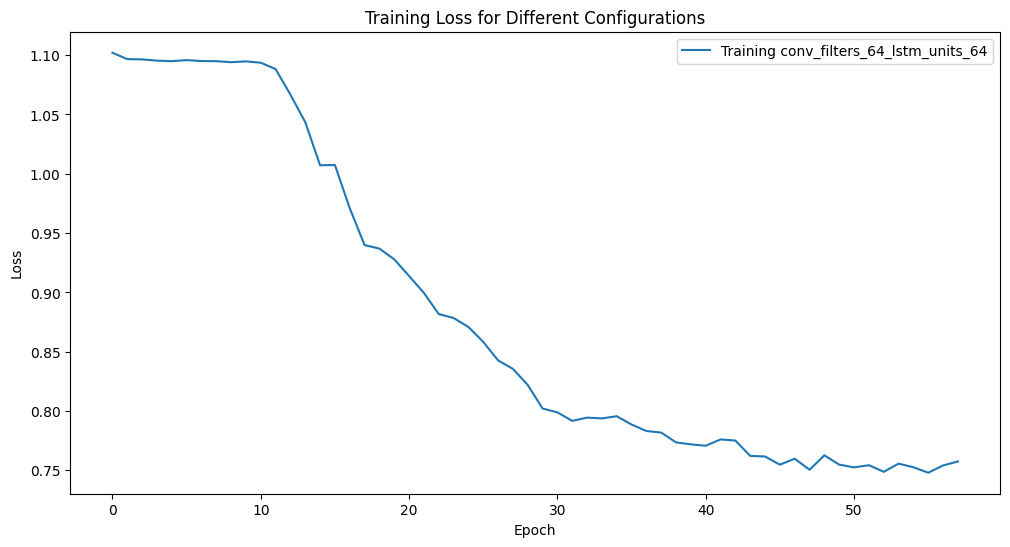

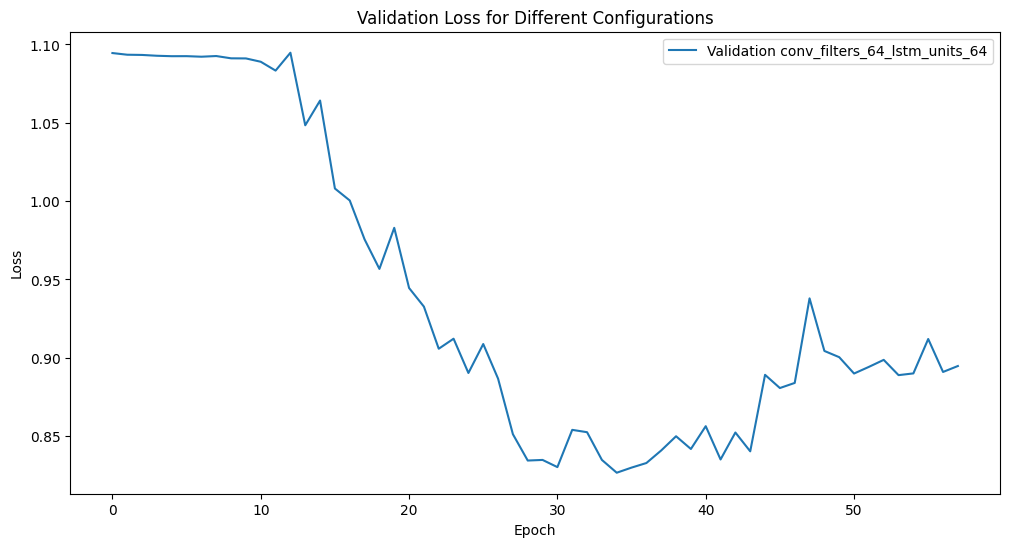

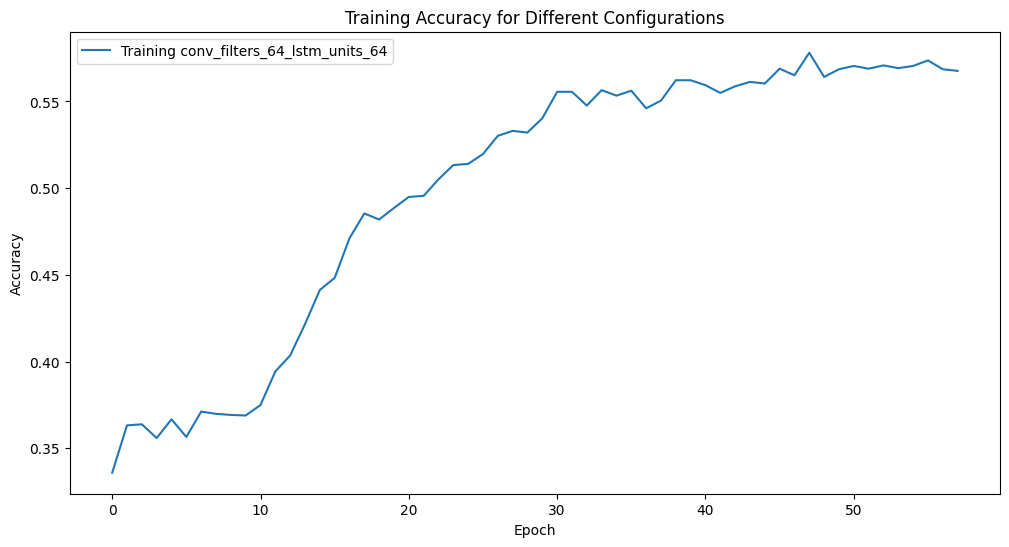

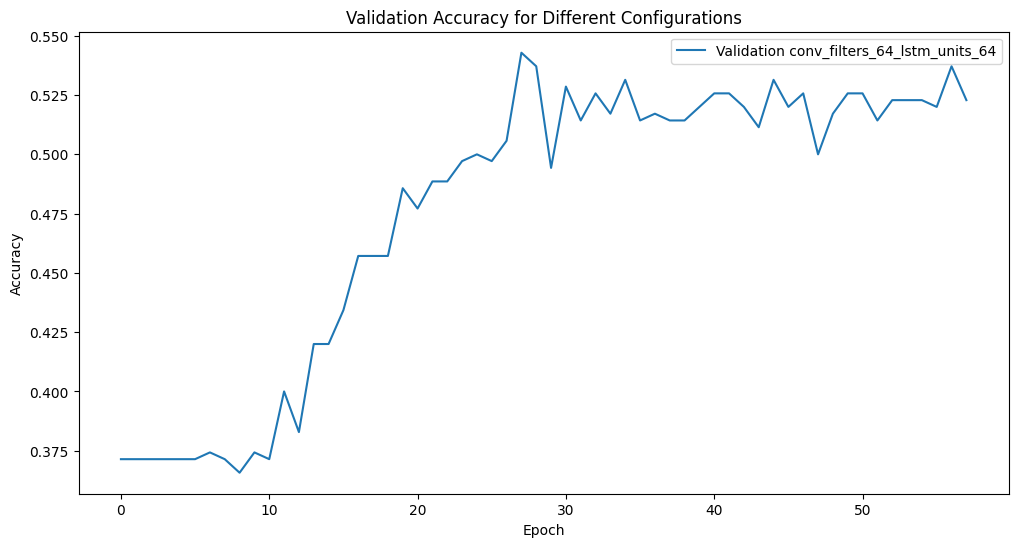

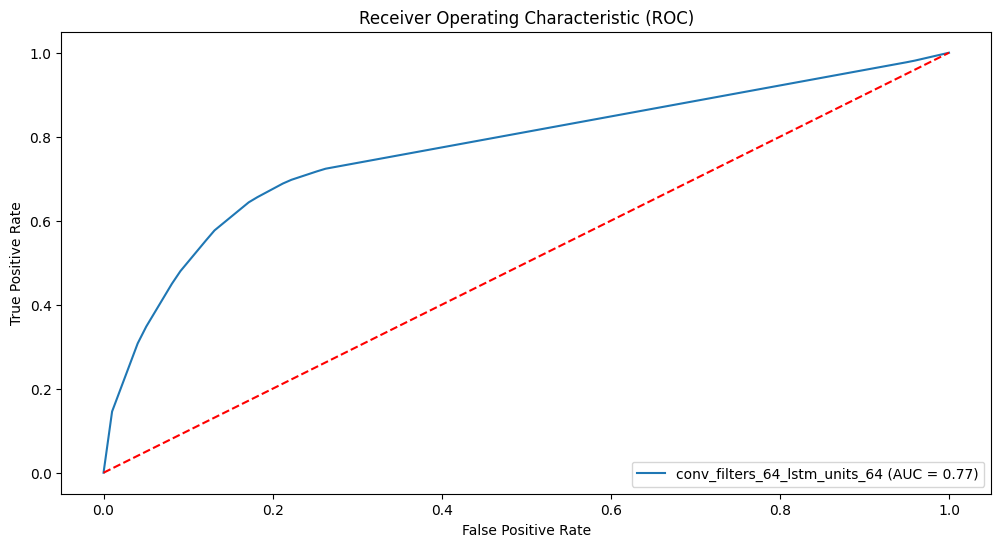

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Get the length of the longest history record
max_len = max([len(history['loss']) for key in results_neurons for history in results_neurons[key]['histories']])

# Define a function to pad history records
def pad_history(history, max_len):
    padded_history = {}
    for key in history:
        padded_history[key] = history[key] + [history[key][-1]] * (max_len - len(history[key]))
    return padded_history

# Pad all history records
padded_results_neurons = {}
for key in results_neurons:
    padded_histories = [pad_history(history, max_len) for history in results_neurons[key]['histories']]
    padded_results_neurons[key] = {
        'histories': padded_histories,
        'mean_fpr': results_neurons[key]['mean_fpr'],
        'mean_tpr': results_neurons[key]['mean_tpr'],
        'mean_auc_curve': results_neurons[key]['mean_auc_curve']
    }

# Plot training loss
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_loss = np.mean([history['loss'] for history in padded_results_neurons[key]['histories']], axis=0)
    plt.plot(mean_loss, label=f'Training {key}')
plt.title('Training Loss for Different Configurations')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot validation loss
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_val_loss = np.mean([history['val_loss'] for history in padded_results_neurons[key]['histories']], axis=0)
    plt.plot(mean_val_loss, label=f'Validation {key}')
plt.title('Validation Loss for Different Configurations')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_accuracy = np.mean([history['accuracy'] for history in padded_results_neurons[key]['histories']], axis=0)
    plt.plot(mean_accuracy, label=f'Training {key}')
plt.title('Training Accuracy for Different Configurations')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot validation accuracy
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_val_accuracy = np.mean([history['val_accuracy'] for history in padded_results_neurons[key]['histories']], axis=0)
    plt.plot(mean_val_accuracy, label=f'Validation {key}')
plt.title('Validation Accuracy for Different Configurations')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot ROC curve
plt.figure(figsize=(12, 6))
for key in padded_results_neurons:
    mean_fpr = padded_results_neurons[key]['mean_fpr']
    mean_tpr = padded_results_neurons[key]['mean_tpr']
    mean_auc = padded_results_neurons[key]['mean_auc_curve']
    plt.plot(mean_fpr, mean_tpr, label=f'{key} (AUC = {mean_auc:.2f})')

plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [ ]:
save_dir = BASE_DIR / "train_weight"
save_dir.mkdir(parents=True, exist_ok=True)

conv_filters=64
lstm_units=64

model = create_model(input_shape, num_classes, conv_filters, lstm_units)
model.fit(data, targets, epochs=25, batch_size=8)
model.save(save_dir / f'violence_detection_model_conv_{conv_filters}_lstm_{lstm_units}_revisedv1.h5')
print(f"Model with conv_filters={conv_filters} and lstm_units={lstm_units} saved.")